# Notebook Dedicated to observe the cos($\alpha$) observable of the bisMSB B8 Nu MC Data

In [2]:
import numpy as np
import glob
import seaborn as sn
import matplotlib.pyplot as plt

# Load Data

In [3]:
#main_dir = '/home/joankl/data/solars/mc/bisMSB/b8Nue/ratds_np/np_files/cos_alpha_*.npy'
#main_dir = 'E:/Data/solars/mc/bisMSB/b8Nue/ratds_np/np_files/'
main_dir = '/lstore/sno/joankl/solar_analysis/mc_data/main_simulations/bisMSB/B8_solar_Nue/ratDS_output/np_files/'

obs_list = ['cos_alpha', 'energy_corr', 'posr']

obs_dict = {var_i: [] for var_i in obs_list}

for obs_i in obs_list:
    flist = glob.glob(main_dir + obs_i + '_*.npy')

    for dir_i in flist:
        load_np = np.load(dir_i)
        obs_dict[obs_i].append(load_np)

    obs_dict[obs_i] = np.concatenate(obs_dict[obs_i])

cos_alpha = obs_dict['cos_alpha']
energy = obs_dict['energy_corr']
posr = obs_dict['posr']

In [3]:
cos_alpha.shape

(290197346,)

# Plots

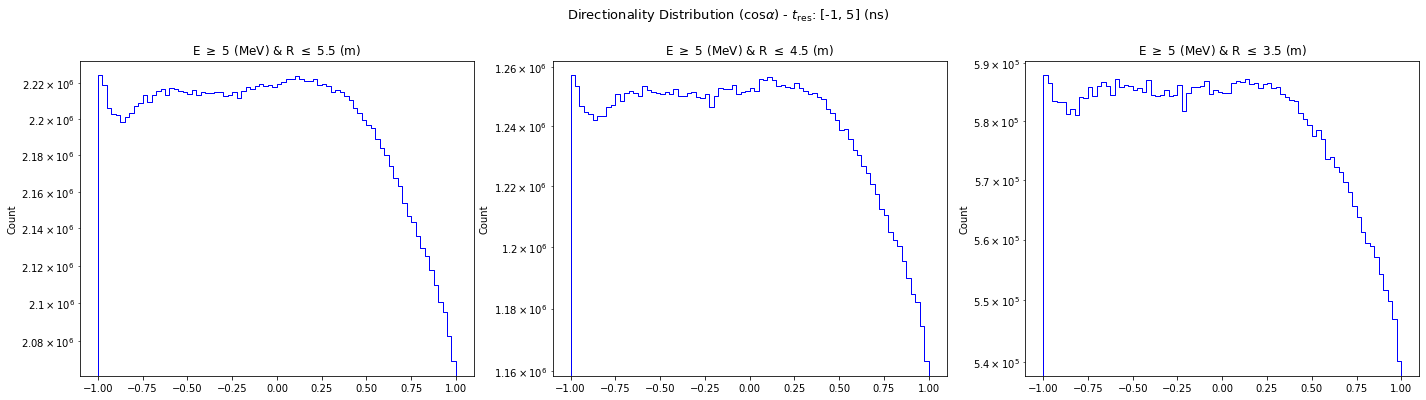

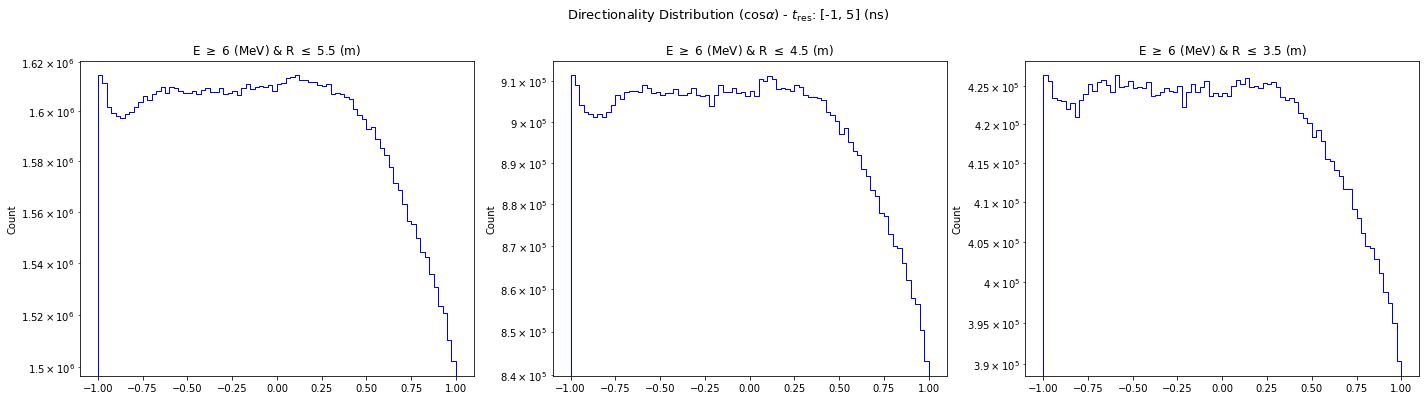

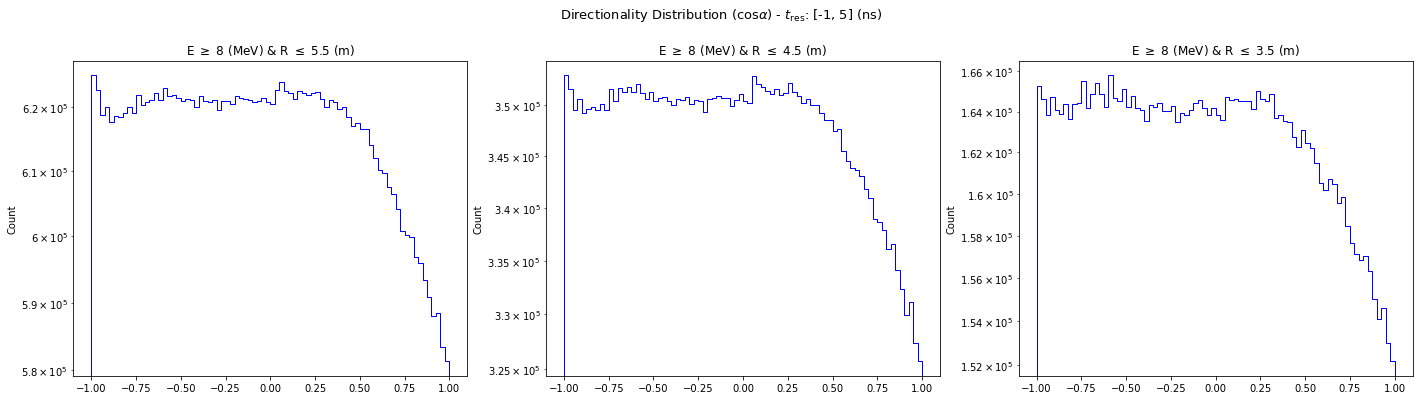

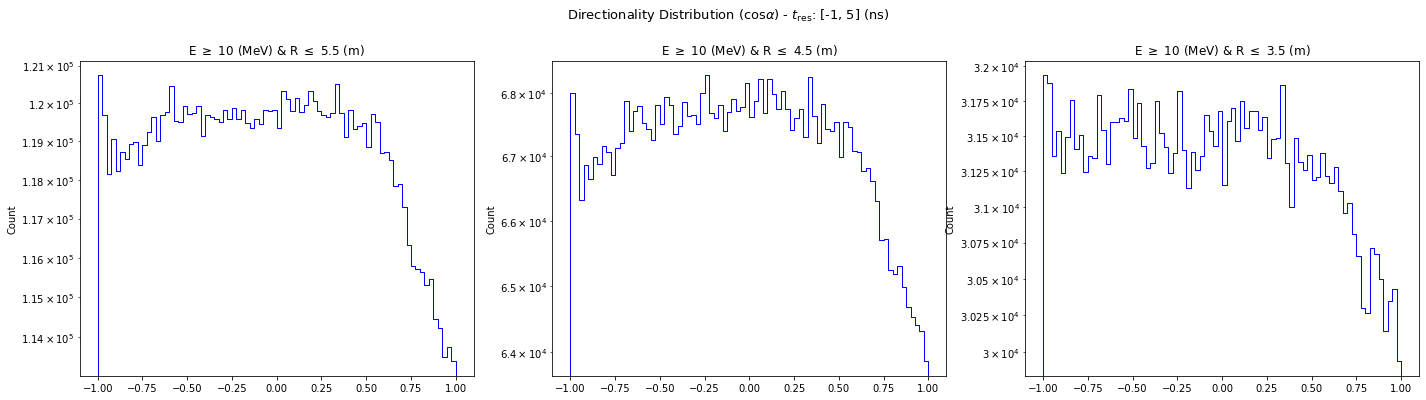

In [7]:
bins = 80
# ------ Define Cuts ------
E_cut_list = [5, 6, 8, 10]
R_cut_list = [5500, 4500, 3500]

for Ecut_i in E_cut_list:
    en_cut_condition = (energy >= Ecut_i)
    
    fig, axes = plt.subplots(1, len(R_cut_list), figsize=(24, 5.8))
    
    for i_dx, Rcut_i in enumerate(R_cut_list):
        posr_cut_condition = (posr <= Rcut_i)
        cut_condition = en_cut_condition & posr_cut_condition
        
        cos_alpha_cut = cos_alpha[cut_condition]
        
        ax = axes[i_dx]
    
        sn.histplot(cos_alpha_cut, ax = ax, bins = bins, alpha = 0, element = 'step', color = 'blue')

        ax.set_title(fr'E $\geq$ {Ecut_i} (MeV) & R $\leq$ {Rcut_i*10**(-3)} (m)')
        ax.set_yscale('log')

    plt.suptitle(r'Directionality Distribution ($\cos\alpha$) - $t_{\mathrm{res}}$: [-1, 5] (ns)', fontsize = 13, y = 1.01)

    plt.show()